In [1]:
import anndata

import dtangle

In [2]:
adata_sum = anndata.read_h5ad("./data/GSE19830_sum.h5ad")
adata_sum

AnnData object with n_obs × n_vars = 42 × 13934
    obs: 'sample_name', 'cel_version', 'nrows', 'ncols', 'algorithm', 'sample_geo_accession', 'sample_name_meta', 'sample_title', 'sample_source_name_ch1', 'sample_organism_ch1', 'sample_platform_id', 'sample_series_id', 'file', 'file_size', 'file_url', 'accession', 'fraction_liver', 'fraction_brain', 'fraction_lung'
    var: 'gene_id', 'n_probes', 'converged'
    uns: 'normalization', 'summarization'

In [3]:
dtangle.deconvolut(
    adata_sum,
    pure_samples_col="accession",
    pure_samples={
        "liver": adata_sum.obs.loc[adata_sum.obs["fraction_liver"] == 1, "accession"].tolist(),
        "brain": adata_sum.obs.loc[adata_sum.obs["fraction_brain"] == 1, "accession"].tolist(),
        "lung": adata_sum.obs.loc[adata_sum.obs["fraction_lung"] == 1, "accession"].tolist(),
    },
)

In [7]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Estimated fraction')

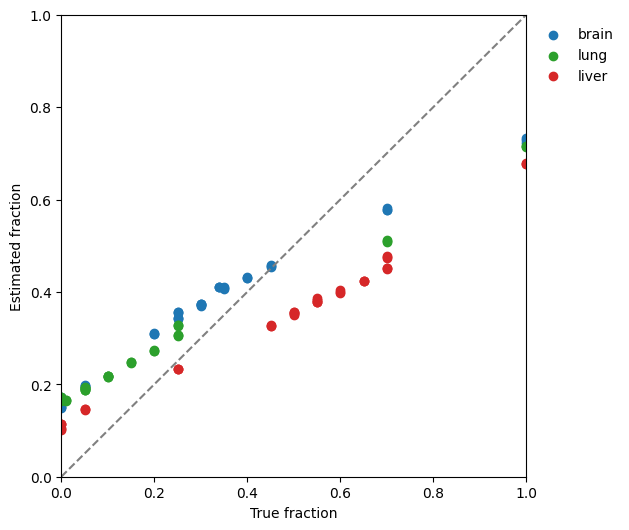

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
for cell_type, color in zip(
    ["brain", "lung", "liver"],
    ["tab:blue", "tab:green", "tab:red"],
    strict=True,
):
    ax.scatter(
        x=adata_sum.obs[f"fraction_{cell_type}"],
        y=adata_sum.obsm["dtangle"][cell_type],
        c=color,
        label=cell_type,
    )
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1, 1),
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.plot([0, 1], [0, 1], c="gray", ls="--")

ax.set_xlabel("True fraction")
ax.set_ylabel("Estimated fraction")